# Jadco Real Estate: XGBoost Market Pricing Model

This notebook constructs a Walk-Forward Backtesting pipeline to forecast building-level rent growth using internal lease data, concessions, and macroeconomic indicators (CMHC & CPI).

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Internal Data Engineering

Here we load the primary Jadco datasets: `Lease History`, `Asking History`, and `Concessions`.
We merge concessions onto the leases and flag properties that are in 'Lease-Up'.

In [55]:
data_dir = "data/"
# On lit les fichiers ET on retire les espaces au début (skipinitialspace)
lease_df = pd.read_csv(data_dir + "equinoxe_lease_history.csv", skipinitialspace=True)
asking_df = pd.read_csv(data_dir + "equinoxe_asking_history.csv", skipinitialspace=True)
conc_df = pd.read_csv(data_dir + 'equinoxe_concessions.csv', skipinitialspace=True)
# Et on nettoie brutalement les noms de colonnes pour enlever tous les espaces invisibles restants
lease_df.columns = lease_df.columns.str.strip()
asking_df.columns = asking_df.columns.str.strip()
conc_df.columns = conc_df.columns.str.strip()

# 1. Process Concessions
conc_df['sDateFrom'] = pd.to_datetime(conc_df['sDateFrom'])
conc_df['sAmount'] = conc_df['sAmount'].fillna(0)

conc_sorted = conc_df.sort_values('sDateFrom')
conc_dummies = pd.get_dummies(conc_sorted['sChargeCode'], prefix='Conc')
conc_processed = pd.concat([conc_sorted[['hUnit', 'sDateFrom']], conc_dummies], axis=1)

# Get max for flags, sum for dollar amounts
conc_amt = conc_sorted.groupby(['hUnit', 'sDateFrom'])['sAmount'].sum().reset_index()
conc_processed = conc_processed.groupby(['hUnit', 'sDateFrom']).max().reset_index()
conc_processed = pd.merge(conc_processed, conc_amt, on=['hUnit', 'sDateFrom'])
conc_processed = conc_processed.sort_values('sDateFrom')

# 2. Merge Concessions onto Leases
lease_df['sLeaseFrom_dt'] = pd.to_datetime(lease_df['sLeaseFrom'])
lease_sorted = lease_df.sort_values('sLeaseFrom_dt')

lease_df = pd.merge_asof(
    lease_sorted,
    conc_processed,
    by='hUnit',
    left_on='sLeaseFrom_dt',
    right_on='sDateFrom',
    direction='backward',
    tolerance=pd.Timedelta('365D')
)

concession_cols = [c for c in lease_df.columns if c.startswith('Conc_')]
lease_df[concession_cols] = lease_df[concession_cols].fillna(0).astype(int)
lease_df['sAmount'] = lease_df['sAmount'].fillna(0)

# 3. Flag 'Lease-Up' Strategy Buildings
established_buildings = ['Daniel-Johnson', 'Levesque']
established_prop_codes = ['stelz1', 'stelz2'] # stelz3 is brand new!

def is_lease_up(row):
    b = str(row['sBuilding']).strip()
    p = str(row['sPropCode']).strip()
    if b in established_buildings:
        return 0
    elif b == 'Saint-Elzear' and p in established_prop_codes:
        return 0
    else:
        return 1

lease_df['Is_LeaseUp'] = lease_df.apply(is_lease_up, axis=1)

# 4. Clean up columns and parse dates
keep_cols = ['Is_LeaseUp', 'hUnit', 'sBuilding', 'sCity', 'sState', 'sTermSeq', 'sRent', 'sRentEffective', 'sBeds', 'sBaths', 'sSqft', 'sUnitType', 'sRenewal', 'sLeaseFrom', 'sTermMonths', 'sAmount'] + concession_cols
lease_df = lease_df[keep_cols].copy()

lease_df['sLeaseFrom'] = pd.to_datetime(lease_df['sLeaseFrom'])
lease_df['LeaseMonth'] = lease_df['sLeaseFrom'].dt.month.astype(str)
lease_df['MergeMonth'] = lease_df['sLeaseFrom'].dt.to_period('M').astype(str)

print(f"Base Lease Data Prepared: {lease_df.shape}")

Base Lease Data Prepared: (4302, 26)


## 2. Target Variable & Market Gaps

We sort the dataframe chronologically to calculate the **Annualized Rent Growth** between sequential leases in the same unit. We also merge the `Asking Rent` from exactly 12 months prior to calculate Market Velocity.

In [56]:
# 1. Calculate Previous Rent & Previous Concessions
lease_df = lease_df.sort_values(by=['hUnit', 'sTermSeq'])
lease_df['Previous_sRentEffective'] = lease_df.groupby('hUnit')['sRentEffective'].shift(1)
lease_df['Previous_sAmount'] = lease_df.groupby('hUnit')['sAmount'].shift(1)
lease_df['Previous_sLeaseFrom'] = lease_df.groupby('hUnit')['sLeaseFrom'].shift(1)

lease_df['Previous_Concession_Ratio'] = lease_df['Previous_sAmount'].abs() / (lease_df['Previous_sRentEffective'] * 12)
lease_df['Previous_Concession_Ratio'] = lease_df['Previous_Concession_Ratio'].fillna(0)

for col in concession_cols:
    lease_df[f'Previous_{col}'] = lease_df.groupby('hUnit')[col].shift(1)

# Drop first term sequences (we can't calculate growth if there is no previous rent)
model_df = lease_df.dropna(subset=['Previous_sRentEffective']).copy()
for col in concession_cols:
    model_df[f'Previous_{col}'] = model_df[f'Previous_{col}'].fillna(0).astype(int)

# 2. Target Variable: Annualized Growth Percentage
model_df['gap_years'] = (model_df['sLeaseFrom'] - model_df['Previous_sLeaseFrom']).dt.days / 365.25
model_df = model_df[model_df['gap_years'] >= 0.1].copy() # Filter mathematically unstable short leases
model_df['growth_pct'] = ((model_df['sRentEffective'] / model_df['Previous_sRentEffective']) ** (1 / model_df['gap_years']) - 1) * 100

# 3. Market Gap & Velocity (Using Asking Rents)
asking_df = asking_df[['hUnit', 'sMonth', 'sAskingRent']].copy()
asking_df['sMonth_dt'] = pd.to_datetime(asking_df['sMonth'] + '-01')
model_df['sLeaseFrom_dt'] = pd.to_datetime(model_df['MergeMonth'] + '-01')
model_df['sLeaseFrom_dt_minus_12m'] = model_df['sLeaseFrom_dt'] - pd.DateOffset(months=12)

asking_sorted = asking_df.sort_values('sMonth_dt')
model_sorted = model_df.sort_values('sLeaseFrom_dt')

# Current asking rent vs previous lease (Loss to Lease)
merged_df = pd.merge_asof(
    model_sorted, 
    asking_sorted, 
    by='hUnit', 
    left_on='sLeaseFrom_dt', 
    right_on='sMonth_dt', 
    direction='backward'
)

# Trailing 12-month asking rent (Velocity)
merged_df = pd.merge_asof(
    merged_df.sort_values('sLeaseFrom_dt_minus_12m'), 
    asking_sorted, 
    by='hUnit', 
    left_on='sLeaseFrom_dt_minus_12m', 
    right_on='sMonth_dt', 
    direction='backward',
    suffixes=('', '_12m_ago')
)

merged_df = merged_df.sort_values(['hUnit', 'sTermSeq'])
merged_df['Market_Gap'] = merged_df['sAskingRent'] - merged_df['Previous_sRentEffective']
merged_df['Market_Gap'] = merged_df['Market_Gap'].fillna(0)
merged_df['Market_Velocity'] = (merged_df['sAskingRent'] - merged_df['sAskingRent_12m_ago']) / merged_df['sAskingRent_12m_ago']
merged_df['Market_Velocity'] = merged_df['Market_Velocity'].fillna(0) 

print(f"Target Variable Engineered. Valid leases: {len(merged_df)}")

Target Variable Engineered. Valid leases: 3241


## 3. Macroeconomic Data (CMHC & CPI)

We merge external datasets to give the model a broader understanding of the real estate landscape (Vacancy Rates, Average Regional Rents, and Inflation).

In [57]:
# 1. CMHC Data Merge
cmhc_df = pd.read_csv(data_dir + "external_data/cmhc_consolidated.csv")
cmhc_df['Date_dt'] = pd.to_datetime(cmhc_df['Date'] + '-01')
cmhc_sorted = cmhc_df.sort_values('Date_dt')

cma_mapping = {'Mont-Royal': 'Montreal', 'Laval': 'Montreal', 'Pointe-Claire': 'Montreal', 'Ottawa': 'Ottawa'}
merged_df['CMA'] = merged_df['sCity'].map(cma_mapping).fillna('Montreal')

unit_mapping = {0: 'Studio', 1: '1 Bedroom', 2: '2 Bedroom', 3: '3 Bedroom +'}
merged_df['Unit_Type_CMHC'] = merged_df['sBeds'].map(unit_mapping)

merged_df = merged_df.sort_values('sLeaseFrom_dt')
merged_df = pd.merge_asof(
    merged_df,
    cmhc_sorted,
    left_on='sLeaseFrom_dt',
    right_on='Date_dt',
    left_by=['CMA', 'Unit_Type_CMHC'],
    right_by=['City', 'Unit_Type'],
    direction='backward'
)

merged_df['Vacancy_Rate_Pct'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Vacancy_Rate_Pct'].transform(lambda x: x.bfill().ffill())
merged_df['Average_Rent'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Average_Rent'].transform(lambda x: x.bfill().ffill())
merged_df['Rent_YoY_Growth_Pct'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Rent_YoY_Growth_Pct'].transform(lambda x: x.bfill().ffill())

merged_df['CMHC_Market_Premium'] = (merged_df['Previous_sRentEffective'] - merged_df['Average_Rent']) / merged_df['Average_Rent']
merged_df['CMHC_Market_Premium'] = merged_df['CMHC_Market_Premium'].fillna(0)

# 2. CPI Inflation Merge (18-Month Lag)
cpi_df = pd.read_csv(data_dir + 'external_data/1810000401_databaseLoadingData.csv')
cpi_df = cpi_df[cpi_df['Products and product groups'] == 'Shelter'].copy()
cpi_df['Date_dt'] = pd.to_datetime(cpi_df['REF_DATE'] + '-01')
cpi_df = cpi_df.sort_values('Date_dt')
cpi_df = cpi_df[['Date_dt', 'VALUE']].rename(columns={'VALUE': 'CPI_Index_Shelter'})

merged_df['LeaseFrom_Lagged_18m'] = merged_df['sLeaseFrom_dt'] - pd.DateOffset(months=18)
merged_df = merged_df.sort_values('LeaseFrom_Lagged_18m')

merged_df = pd.merge_asof(
    merged_df,
    cpi_df,
    left_on='LeaseFrom_Lagged_18m',
    right_on='Date_dt',
    direction='backward'
)
merged_df['CPI_Index_Shelter'] = merged_df['CPI_Index_Shelter'].bfill().ffill()

# Impute minor missing data
merged_df['sBaths'] = merged_df['sBaths'].fillna(merged_df['sBaths'].median())
merged_df['sSqft'] = merged_df['sSqft'].fillna(merged_df['sSqft'].median())
merged_df['sTermMonths'] = merged_df['sTermMonths'].fillna(12)

print("Macro Data Merged Successfully.")

Macro Data Merged Successfully.


## 4. Building-Level Aggregation

To strip out the extreme noise of individual human negotiations (outliers like +1200% or -65%), we aggregate the dataset into **Building-Level Monthly Averages**. This transforms the model from a micro-predictor into a macro-forecaster.

In [58]:
import pandas as pd

# 1. Lecture du fichier (on ignore les 8 premières lignes de texte d'introduction)
# Le séparateur est un point-virgule (;)
df_brut = pd.read_csv('taux_directeur.csv', sep=';', skiprows=8, header=None)

# 2. Extraction des bonnes lignes (Dates sur la ligne 1, Taux sur la ligne 3)
dates_raw = df_brut.iloc[1, 1:].values
taux_raw = df_brut.iloc[3, 1:].values  # "Taux officiel d'escompte"

# 3. Création d'un tableau propre
df_taux = pd.DataFrame({
    'date_str': dates_raw, 
    'taux_directeur': taux_raw
})

# 4. Nettoyage mathématique : on remplace la virgule par un point et on convertit en chiffre
df_taux['taux_directeur'] = df_taux['taux_directeur'].astype(str).str.replace(',', '.').astype(float)

# 5. Dictionnaire magique pour traduire les mois français en chiffres
mois_fr = {
    'janvier': '01', 'février': '02', 'mars': '03', 'avril': '04', 
    'mai': '05', 'juin': '06', 'juillet': '07', 'août': '08', 
    'septembre': '09', 'octobre': '10', 'novembre': '11', 'décembre': '12'
}

# Fonction pour convertir "1 janvier 2020" en vraie Date informatique
def parse_date(d):
    mots = str(d).split()
    if len(mots) == 3:
        jour, mois, annee = mots[0], mots[1], mots[2]
        return pd.to_datetime(f"{annee}-{mois_fr[mois.lower()]}-{int(jour):02d}")
    return pd.NaT

df_taux['date'] = df_taux['date_str'].apply(parse_date)

# 6. Extraction de l'année
df_taux['year'] = df_taux['date'].dt.year

# 7. LE RÉSULTAT FINAL : On calcule la moyenne du taux directeur pour chaque année
taux_annuel = df_taux.groupby('year')['taux_directeur'].mean().reset_index()
taux_annuel['taux_directeur'] = taux_annuel['taux_directeur'].round(2) # Arrondir à 2 décimales

print("Succès ! Voici le tableau prêt à être injecté dans l'IA :")
print(taux_annuel)


Succès ! Voici le tableau prêt à être injecté dans l'IA :
   year  taux_directeur
0  2020            0.81
1  2021            0.50
2  2022            2.16
3  2023            4.99
4  2024            4.82
5  2025            2.96
6  2026            2.50


In [ ]:
# 1. Drop extreme unit-level outliers first to avoid poisoning the averages
valid_mask = merged_df['growth_pct'].between(-25, 50)
clean_df = merged_df[valid_mask].copy()
clean_df['Lease_Year'] = clean_df['sLeaseFrom_dt'].dt.year

print(f"Original unit-level rows: {len(clean_df)}")

# 2. AGGREGATE TO BUILDING-MONTH LEVEL
bldg_df = clean_df.groupby(['sBuilding', 'Lease_Year', 'LeaseMonth']).agg(
    growth_pct=('growth_pct', 'mean'),
    CPI_Index_Shelter=('CPI_Index_Shelter', 'mean'),
    Is_LeaseUp=('Is_LeaseUp', 'max'),
    Market_Gap=('Market_Gap', 'mean'),
    Market_Velocity=('Market_Velocity', 'mean'),
    Vacancy_Rate_Pct=('Vacancy_Rate_Pct', 'mean'),
    Rent_YoY_Growth_Pct=('Rent_YoY_Growth_Pct', 'mean'),
    CMHC_Market_Premium=('CMHC_Market_Premium', 'mean'),
    Previous_sRentEffective=('Previous_sRentEffective', 'mean'),
    Previous_Concession_Ratio=('Previous_Concession_Ratio', 'mean'),
    Lease_Count=('hUnit', 'count')
).reset_index()

# 3. Filter out noise (months where only 1 or 2 random leases were signed)
bldg_df = bldg_df[bldg_df['Lease_Count'] >= 3].copy()
print(f"Aggregated Building-Month rows: {len(bldg_df)}")

# We intentionally drop `sBuilding` to prevent the model from memorizing building names.
# This forces the model to rely on `Is_LeaseUp` and macro data, allowing it to predict future brand new buildings!
features = [
    'Lease_Year', 'LeaseMonth', 'CPI_Index_Shelter', 'Is_LeaseUp', 
    'Market_Gap', 'Market_Velocity', 'Vacancy_Rate_Pct', 
    'Rent_YoY_Growth_Pct', 'CMHC_Market_Premium', 
    'Previous_sRentEffective', 'Previous_Concession_Ratio',
    #'taux_directeur'
]

# --- AJOUT DU TAUX DIRECTEUR ---
# On s'assure que notre tableau taux_annuel a la même colonne d'année que bldg_df
# taux_annuel = taux_annuel.rename(columns={'year': 'Lease_Year'})

# On fusionne le taux directeur au tableau bldg_df
# 
# 
# bldg_df = bldg_df.merge(taux_annuel, on='Lease_Year', how='left')
# -------------------------------

X = bldg_df[features].copy()
y = bldg_df['growth_pct']

# Dummy encoding for Seasonality
X = pd.get_dummies(X, columns=['LeaseMonth'], drop_first=True)
print(f"Final aggregated dataset ready. Shape: {X.shape}")

Original unit-level rows: 3241
Aggregated Building-Month rows: 293
Final aggregated dataset ready. Shape: (293, 21)


## 5. Walk-Forward Backtesting (XGBoost)

We simulate a real-world deployment by training the model strictly on past data (e.g., `< 2024`) and testing it exclusively on future unseen data (e.g., `== 2024`).

In [60]:
target_years = [2023, 2024, 2025]
results = []
models = {}

print("Starting Walk-Forward Backtesting for XGBoost...")

for year in target_years:
    print(f"\n--- Backtesting Year: {year} ---")
    
    # Train: All data strictly BEFORE the target year
    train_mask = X['Lease_Year'] < year
    # Test: All data strictly IN the target year
    test_mask = X['Lease_Year'] == year
    
    X_train = X[train_mask].drop(columns=['Lease_Year']).astype(float)
    y_train = y[train_mask]
    
    X_test = X[test_mask].drop(columns=['Lease_Year']).astype(float)
    y_test = y[test_mask]
    
    if len(X_test) == 0:
        print(f"Skipping {year} - No test data available.")
        continue
        
    print(f"Training on {len(X_train)} samples, Testing on {len(X_test)} samples.")
    
    # Initialize and train XGBoost
    # Reduced depth and estimators to prevent overfitting on the smaller aggregated dataset
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )
    
    xgb_model.fit(X_train, y_train)
    models[year] = xgb_model
    
    # Predict
    preds = xgb_model.predict(X_test)
    
    # Evaluate (No R2, only Mean Absolute Error)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    print(f"Results for {year}: MAE = {mae:.4f}% | RMSE = {rmse:.4f}%")
    results.append({
        'Year': year,
        'MAE': mae,
        'RMSE': rmse
    })

# Summary
res_df = pd.DataFrame(results)
print("\n--- Average Out-of-Sample Performance (XGBoost) ---")
print(res_df.mean(numeric_only=True))

Starting Walk-Forward Backtesting for XGBoost...

--- Backtesting Year: 2023 ---
Training on 129 samples, Testing on 35 samples.


Results for 2023: MAE = 2.4041% | RMSE = 2.6621%

--- Backtesting Year: 2024 ---
Training on 164 samples, Testing on 60 samples.
Results for 2024: MAE = 1.8900% | RMSE = 2.6277%

--- Backtesting Year: 2025 ---
Training on 224 samples, Testing on 69 samples.
Results for 2025: MAE = 2.0389% | RMSE = 2.5062%

--- Average Out-of-Sample Performance (XGBoost) ---
Year    2024.000000
MAE        2.111016
RMSE       2.598686
dtype: float64


## 6. Walk-Forward Backtesting (Random Forest)

We run the exact same backtesting loop using a Random Forest to compare architecture performance.

In [61]:
from sklearn.ensemble import RandomForestRegressor

print("Starting Walk-Forward Backtesting for Random Forest...")

rf_results = []
rf_models = {}

for year in target_years:
    print(f"\n--- Backtesting Year: {year} ---")
    
    train_mask = X['Lease_Year'] < year
    test_mask = X['Lease_Year'] == year
    
    X_train = X[train_mask].drop(columns=['Lease_Year']).astype(float)
    y_train = y[train_mask]
    
    X_test = X[test_mask].drop(columns=['Lease_Year']).astype(float)
    y_test = y[test_mask]
    
    if len(X_test) == 0:
        continue
        
    # Initialize and train Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=3,
        random_state=42
    )
    
    rf_model.fit(X_train, y_train)
    rf_models[year] = rf_model
    
    # Predict
    preds = rf_model.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    print(f"RF Results for {year}: MAE = {mae:.4f}% | RMSE = {rmse:.4f}%")
    rf_results.append({
        'Year': year,
        'MAE': mae,
        'RMSE': rmse
    })

res_df_rf = pd.DataFrame(rf_results)
print("\n--- Average Out-of-Sample Performance (Random Forest) ---")
print(res_df_rf.mean(numeric_only=True))

Starting Walk-Forward Backtesting for Random Forest...

--- Backtesting Year: 2023 ---
RF Results for 2023: MAE = 2.3160% | RMSE = 2.5841%

--- Backtesting Year: 2024 ---
RF Results for 2024: MAE = 1.8894% | RMSE = 2.5887%

--- Backtesting Year: 2025 ---
RF Results for 2025: MAE = 1.3608% | RMSE = 1.7257%

--- Average Out-of-Sample Performance (Random Forest) ---
Year    2024.000000
MAE        1.855405
RMSE       2.299516
dtype: float64


## 7. Model Interpretability

Finally, we analyze the Feature Importances to verify that the model is making logical decisions based on macroeconomic realities.

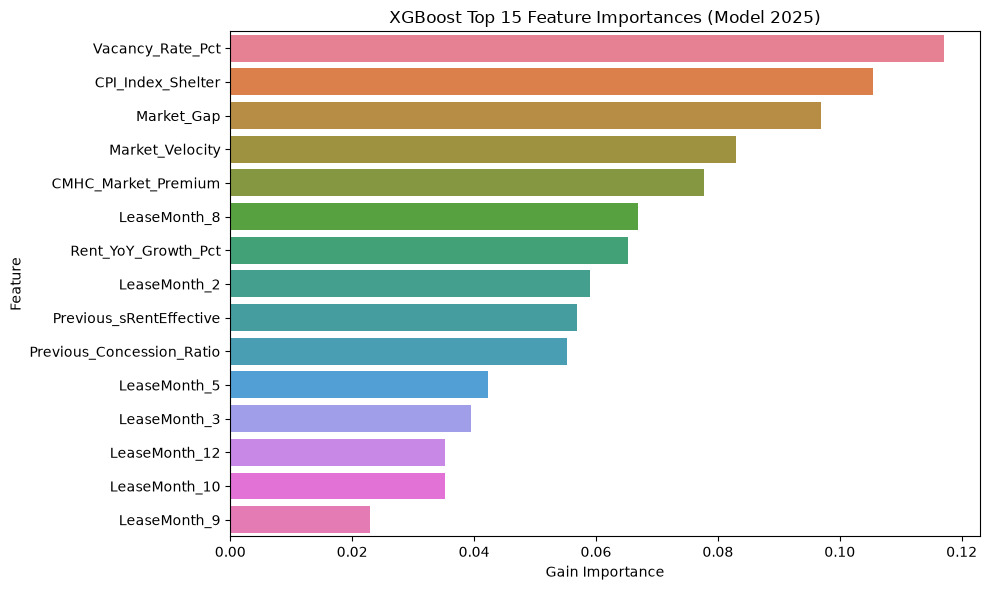

In [62]:
# Feature Importance (using the XGBoost model from the final year)
last_year = target_years[-1]
final_model = models[last_year]

imp_df = pd.DataFrame({
    'Feature': X.drop(columns=['Lease_Year']).columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', hue='Feature', legend=False)
plt.title(f'XGBoost Top 15 Feature Importances (Model {last_year})')
plt.xlabel('Gain Importance')
plt.tight_layout()
plt.show()